# Dynamic Hedging & PnL Attribution

## Step 0 - Importing packages

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Step 1 - Simulate Market Path

To simulate a market path, we can use Geometric Brownian Motion (GBM):

$$S_t = S_0 \cdot \text{exp}\large[\big(\mu - \frac{\sigma^2}{2}\big)t + \sigma W_t\large]$$

where $W_t = \sqrt{t}\varepsilon$, with $\varepsilon \sim \mathcal{N}(0,1)$.

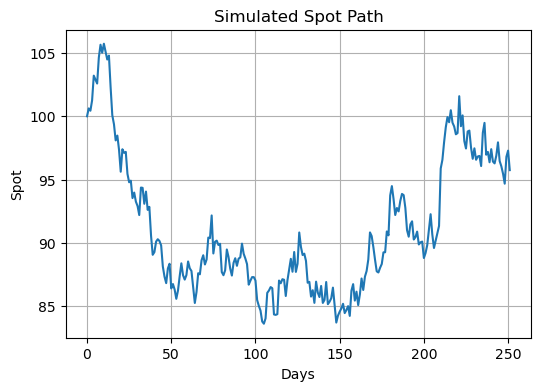

In [80]:
# Set a seed
np.random.seed(42)

# Parameters
S0 = 100
r = 0         # = mu (expected return)
sigma = 0.2
T = 1
N = 252
dt = T/N

# Simulate a GBM
S = np.zeros(N)
S[0] = S0

for t in range(1,N):
    Z = np.random.normal()
    S[t] = S[t-1] * np.exp((r-0.5*sigma**2)*dt + sigma * np.sqrt(dt) * Z)

# PLot the path
plt.figure(figsize=(6,4))
plt.plot(S)
plt.title("Simulated Spot Path")
plt.xlabel("Days")
plt.ylabel("Spot")
plt.grid()
plt.show()

## Step 2 - Dynamic Delta Hedging

We assume selling an ATM call. If spot price rises, we buy delta shares to hedge. If market drop, we sell shares to reduce hedge.

Intuition: As a seller, we want the price to stay below the strike !

**Delta hedging**: At each time:
1. Compute option price
2. Compute Delta
3. Hedge by shorting Delta shares
4. Track cash account

In [82]:
# Function to compute the option price
def bs_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S-K,0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# Function to compute delta = N(d1)
def bs_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1 if S > K else 0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    return norm.cdf(d1)

# Parameters
position = - 1 # call: 1, put = -1
K = 100      # = S0 since we assume ATM
price_0 = bs_price(S[0], K, T, r, sigma) # Call price at t=0
delta_old = 0
cash = price_0  # Sell the call and receive the premium

for t in range(N-1): # No hedging at maturity
    tau = T - t*dt
    delta = bs_delta(S[t], K, tau, r, sigma)
    
    # Rebalance: Buy/Sell stock to match new delta
    # If delta increases, buy more stock (cash goes down)
    cash += position * (delta - delta_old) * S[t]
    delta_old = delta

# Payoff for the buyer
payoff = max(S[-1] - K, 0)

# P&L = [Value of Stock held] + [Remaining Cash] - [Option Payoff you must pay]
pnl = (delta_old * S[-1]) + cash - payoff
print("Final PnL", pnl)

Final PnL 0.09886372504529373


PnL is positive so there is a benefit for the seller. With BS, if implied vol = actual vol, pnl will be 0. But when implied vol > actual vol, the option is overpriced in t = 0 (sold at high premium), so postive PnL.

## Step 3 - Gamma scalping strategy

We simulate a short call + delta hedge and track PnL from Gamma movements.

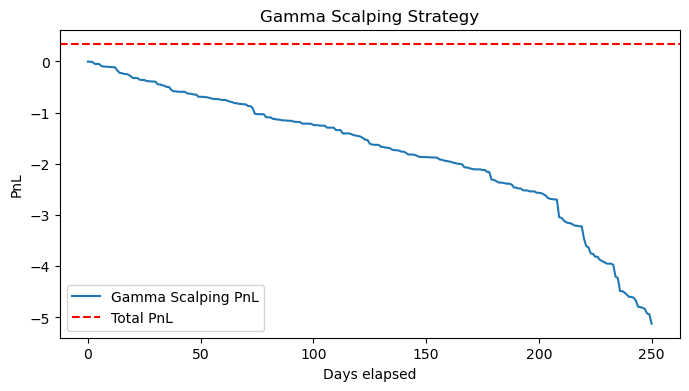

In [42]:
# Function to compute Gamma
def bs_gamma(S, K, T, r, sigma):
    if T <= 0:
        return 0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    return norm.pdf(d1)/(S*sigma*np.sqrt(T))

# Parameters
S0 = 100
K = 100
T = 1
r = 0
sigma = 0.2
N = 252
dt = T/N

# Gamma scalping variables
position = -1
cash = bs_price(S0,K,T,r,sigma)
delta_old = 0
gamma_pnl = []

# Looping over time
for t in range(N-1):
    tau = T - dt*t
    delta = bs_delta(S[t],K,tau,r,sigma)
    gamma = bs_gamma(S[t],K,tau,r,sigma)

    # Rebalancing hedge
    cash += position * (delta - delta_old) * S[t]
    delta_old = delta

    # Track Gamma PnL
    dS = S[t+1] - S[t]
    gamma_pnl.append(position*0.5*gamma*dS**2)

# Final PnL
payoff = max(S[-1] - K, 0)
pnl_total = cash + delta_old*S[-1] - payoff

# Plot
plt.figure(figsize=(8,4))
plt.plot(np.cumsum(gamma_pnl), label = "Gamma Scalping PnL")
plt.axhline(pnl_total, color="red", linestyle="--", label = "Total PnL")
plt.title("Gamma Scalping Strategy")
plt.xlabel("Days elapsed")
plt.ylabel("PnL")
plt.legend()
plt.show()
    

- With a short call, we have short Gamma. So everytime the stock moves, we are forced to "buy high & sell low" to keep Delta at 0. This downward trend shows losses piling up day after day.
- Final value of -5 indicates that we spent 5 units of PnL over 252 days.
- The slope is steeper at the end because the stock moves back towards K = 100 (ATM), making Gamma exploding and more expensive to hedge.

## Step 4 - P&L Attribution

We now compose daily PnL:

$$dV \approx \Delta dS + \frac{1}{2} \Gamma dS^2 + \Theta dt$$

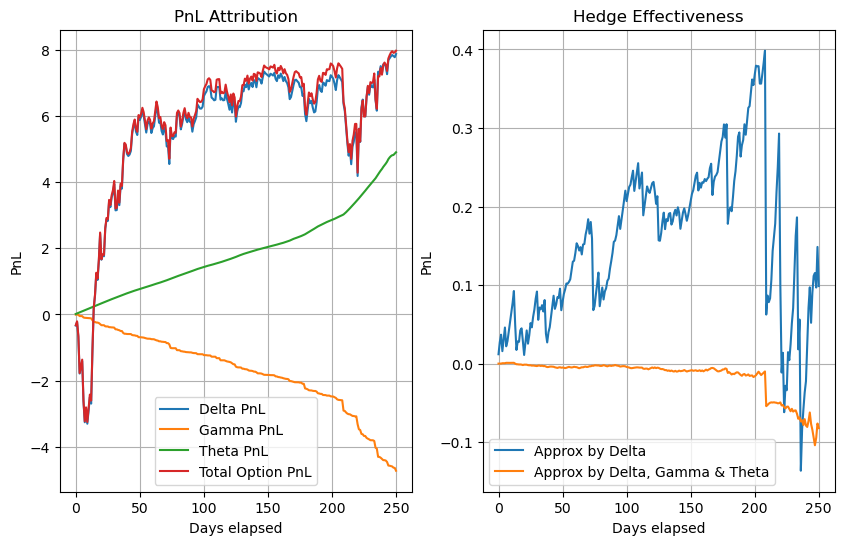

In [85]:
# Parameters
position = -1 # call: 1, put: -1
K = 100       # = S0 since we assume ATM
price_0 = bs_price(S[0], K, T, r, sigma) # Call price at t=0
delta_old = 0
cash = price_0  # Sell the call and receive the premium
delta_pnl = []
gamma_pnl = []
theta_pnl = []
total_pnl = []

# Looping over time
for t in range(N-1):
    # Time elapsed
    tau = T - t*dt 

    # Compute price, delta and gamma
    price = bs_price(S[t], K, tau, r, sigma)
    delta = bs_delta(S[t], K, tau, r, sigma)
    gamma = bs_gamma(S[t], K, tau, r, sigma)

    # Approximate theta numerically
    price_dt = bs_price(S[t], K, tau-dt, r, sigma)
    theta = (price_dt - price)/dt

    # Compute change in option value
    dV = position * (bs_price(S[t+1], K, tau-dt, r, sigma) - price)

    # Attribution
    dS = S[t+1] - S[t]
    delta_term = position * delta * dS
    gamma_term = position * 0.5*gamma*dS**2
    theta_term = position * theta*dt
    
    # Add to vectors
    delta_pnl.append(delta_term)
    gamma_pnl.append(gamma_term)
    theta_pnl.append(theta_term)
    total_pnl.append(dV)

# Plot cumulative contributions
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.plot(np.cumsum(delta_pnl), label = "Delta PnL")
plt.plot(np.cumsum(gamma_pnl), label = "Gamma PnL")
plt.plot(np.cumsum(theta_pnl), label = "Theta PnL")
plt.plot(np.cumsum(total_pnl), label = "Total Option PnL")
plt.title("PnL Attribution")
plt.xlabel("Days elapsed")
plt.ylabel("PnL")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(np.cumsum(np.array(total_pnl) - np.array(delta_pnl)), label = "Approx by Delta")
plt.plot(np.cumsum(np.array(total_pnl) - np.array(delta_pnl) - np.array(gamma_pnl) - np.array(theta_pnl)), label = "Approx by Delta, Gamma & Theta")
plt.title("Hedge Effectiveness")
plt.xlabel("Days elapsed")
plt.ylabel("PnL")
plt.legend()
plt.grid()
plt.show()

- Delta P&L is really close to the dV: Option price is explained by directional exposure (logic since 1st derivative).
- Gamma is largest ATM and decreases when ITM/OTM or when time passes (Theta increases). They naturally offset each other.
- If we're delta hedging properly, the interesting object is $d\Pi = \Delta dS - dV$, which is the true hedge PnL.
  - If using only Delta, we overestimate the true P&L since this estimation results to positive P&L (0.0988) as found before.
  - If adding Gamma and Theta, we notice a negative PnL at maturity, which means that the cost of rebalancing (Gamma) outperforms the time decay (Theta), since there are lots of rises and drops (forcing to buy and sell shares to rebalance Delta -- cost money).

## Step 5 - Hedging Frequency Comparison

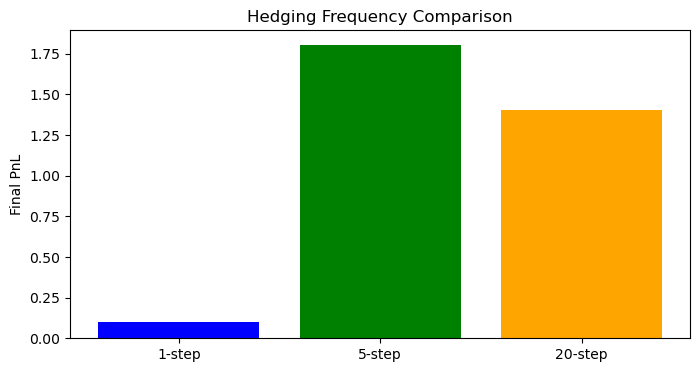

In [91]:
# Parameters
position = -1 # call: 1, put: -1
K = 100       # = S0 since we assume ATM
frequencies = [1, 5, 20] # 1: daily, 5: every 5 days, 20: weekly
pnl_dict = {}

# Looping over frequencies
for freq in frequencies:
    cash = bs_price(S0,K,T,r,sigma)
    delta_old = 0
    for t in range(0,N-1,freq):
        tau = T - dt*t
        delta = bs_delta(S[t],K,tau,r,sigma)
        cash += position * (delta - delta_old) * S[t]
        delta_old = delta
    payoff = max(S[-1] - K, 0)
    pnl_dict[f"{freq}-step"] = cash + delta_old*S[-1] - payoff

# Plotting
plt.figure(figsize=(8,4))
plt.bar(pnl_dict.keys(), pnl_dict.values(), color = ["blue","green","orange"])
plt.title("Hedging Frequency Comparison")
plt.ylabel("Final PnL")
plt.show()

- Lower frequency → residual risk increases : For daily model, the PnL sticks to the theoretical model (paying insurance for hedging, keeping the profit low but certain). But with infrequent hedging, we are exposed to the "Gap risk" (however, in this case, the stock moves in favor by staying low so this risk actually makes higher profit without over-paying insurance).
- By hedging daily, we will smooth out the Gamma costs while it's more stuttering for less frequent hedging.

## Step 6 - Transaction Cost Simulation

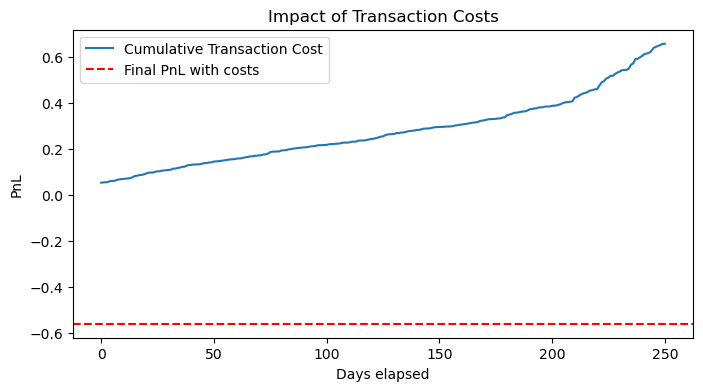

In [98]:
# Parameters
commission = 0.001 # 0.1% per trade
position = -1 # call: 1, put: -1
K = 100       # = S0 since we assume ATM
cash = bs_price(S0,K,T,r,sigma)
delta_old = 0
tc_cost = []

# Looping over time
for t in range (N-1):
    tau = T - dt*t
    delta = bs_delta(S[t],K,tau,r,sigma)
    trade_cost = commission * abs(delta - delta_old) * S[t]
    cash += position*(delta - delta_old)*S[t] - trade_cost
    delta_old = delta
    tc_cost.append(trade_cost)

payoff = max(S[-1] - K, 0)
pnl_with_costs = cash + delta_old*S[-1] - payoff

# Plotting
plt.figure(figsize=(8,4))
plt.plot(np.cumsum(tc_cost), label = "Cumulative Transaction Cost")
plt.axhline(pnl_with_costs, color = "red", linestyle = "--", label = "Final PnL with costs")
plt.title("Impact of Transaction Costs")
plt.ylabel("PnL")
plt.xlabel("Days elapsed")
plt.legend()
plt.show()

This analysis shows that while the mathematical model looks really great with PnL = +0.0988, the physical act of trading can turn a profit into a loss due to transaction costs.

## Step 7 - Intraday Rebalancing Instability (Add jumps)

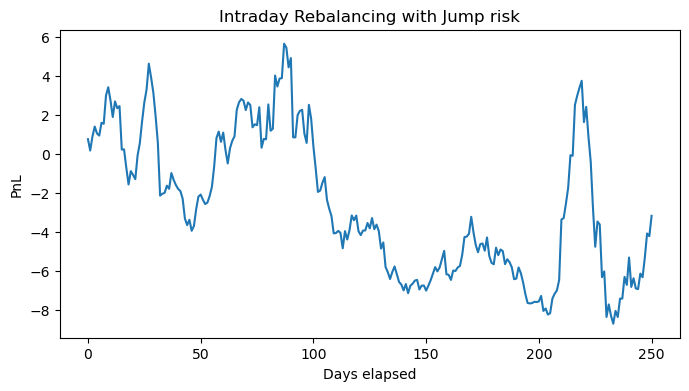

In [112]:
# Simulation of jumps
S_jump = [S0]
for t in range(N):
    dS = S_jump[-1] * (r*dt + sigma*np.sqrt(dt)*np.random.randn())
    # Occasional jump
    if np.random.rand() < 0.02:
        dS += np.random.choice([-5,5])
    S_jump.append(S_jump[-1]+dS)
S_jump = np.array(S_jump)

# Parameters
position = -1 # call: 1, put: -1
K = 100       # = S0 since we assume ATM
cash = bs_price(S0,K,T,r,sigma)
delta_old = 0
pnl_intraday = []

# Delta hedging
for t in range(N-1):
    tau = T - dt*t
    delta = bs_delta(S_jump[t],K,tau,r,sigma)
    cash += position * (delta - delta_old) * S_jump[t]
    delta_old = delta
    pnl_intraday.append(cash + delta_old*S_jump[t] - max(S_jump[-1] - K, 0))

# Plotting
plt.figure(figsize=(8,4))
plt.plot(pnl_intraday)
plt.title("Intraday Rebalancing with Jump risk")
plt.xlabel("Days elapsed")
plt.ylabel("PnL")
plt.show()

- Shows residual risk spikes due to jumps.
- Delta hedge cannot perfectly track sudden moves.

## Step 8 - Volatility Regime Switching

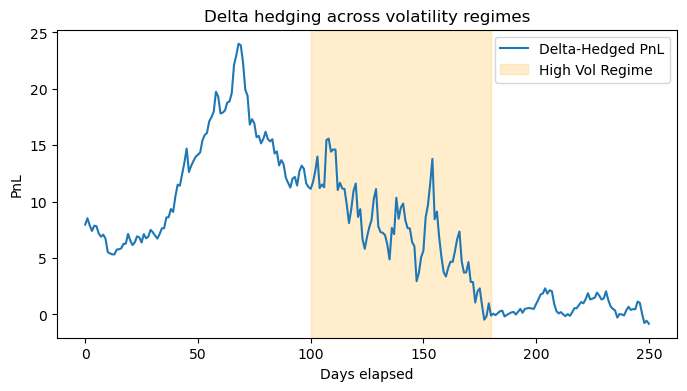

In [131]:
# Simulation of valatility 
sigma_path = np.ones(N)*0.15
sigma_path[100:180] = 0.35 # high vol regime

# Simulation of path
S_vol = [S0]
for i in range(N):
    dS = S_vol[-1]*(r*dt + sigma_path[i]*np.sqrt(dt)*np.random.randn())
    S_vol.append(S_vol[-1]+dS)
S_vol = np.array(S_vol)

# Parameters
position = -1 # call: 1, put: -1
K = 100       # = S0 since we assume ATM
cash = bs_price(S0,K,T,r,sigma)
delta_old = 0
pnl_volregime = []

# Delta hedging
for t in range(N-1):
    tau = T - dt*t
    delta = bs_delta(S_vol[t],K,tau,r,sigma_path[t])
    cash += position*(delta - delta_old)*S_vol[t]
    delta_old = delta
    pnl_volregime.append(cash + delta_old*S_vol[t] - max(S_vol[-1] - K, 0))

# Plotting
plt.figure(figsize=(8,4))
plt.plot(pnl_volregime, label = "Delta-Hedged PnL")
plt.title("Delta hedging across volatility regimes")
plt.axvspan(100,180, color="orange", alpha = 0.2, label = "High Vol Regime")
plt.xlabel("Days elapsed")
plt.ylabel("PnL")
plt.legend()
plt.show()

We can easily see PnL drops or spikes during high volatility regime, which highlights the model risk: static implied volatility assumption may underestimate Gamma losses.